## SALES PREDICTION USING PYTHON

## IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
import xgboost as xgb

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.tree import export_graphviz
from sklearn import tree
from IPython.display import SVG,display
from graphviz import Source

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv("C:\\Users\\Aalhad Ramteke\\Downloads\\Advertising data.csv")

## EXPLORATORY DATA ANALYSIS

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [5]:
df.shape

(200, 5)

In [6]:
df.info

<bound method DataFrame.info of      Unnamed: 0     TV  Radio  Newspaper  Sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]>

In [7]:
duplicates = df.duplicated().sum()
print(duplicates)

0


In [8]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [9]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [10]:
df.dtypes

Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

In [11]:
df.isnull().any()

Unnamed: 0    False
TV            False
Radio         False
Newspaper     False
Sales         False
dtype: bool

In [12]:
df.info

<bound method DataFrame.info of      Unnamed: 0     TV  Radio  Newspaper  Sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]>

Insights generated:
* The Advertising dataset consists of Sales of TV, Radio and Newspaper.
* There are 200 rows and 5 columns provided in the data.
* No duplicate values exist in the dataset.
* Null values not exist in the dataset.

## DATA WRANGLING

In [13]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [14]:
dependent_variable = ['Sales']

## DATA VISUALIZATION

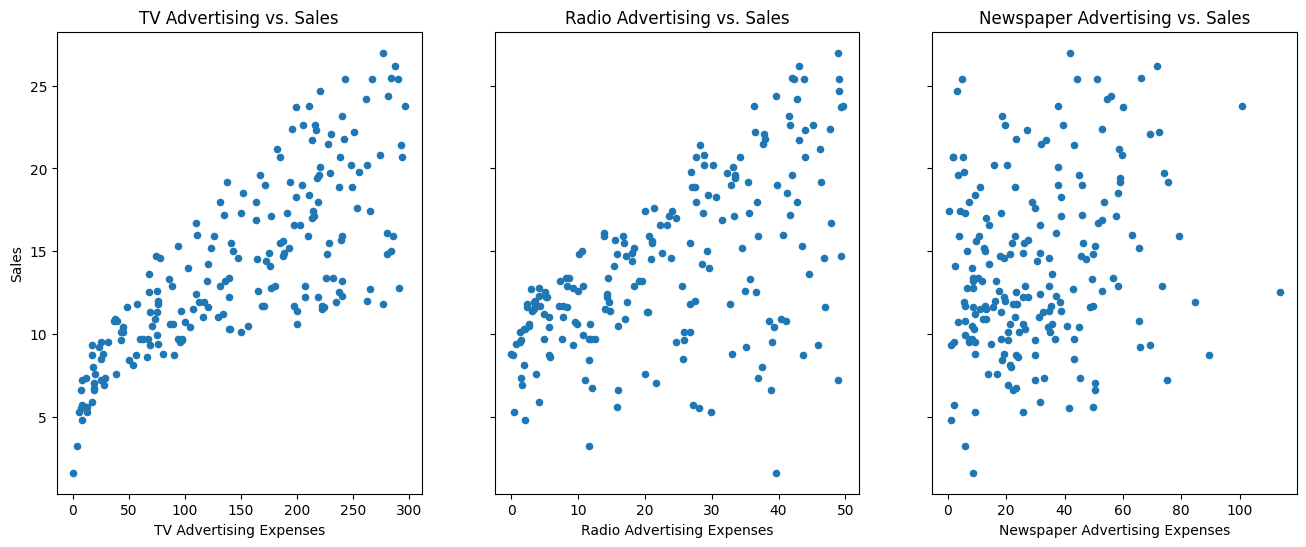

In [15]:
# Chart 1 - Scatterplot visualization code for numerical variable vs target variable

fig, axs = plt.subplots(1, 3, sharey=True, figsize=(16, 6))

# Scatter plot for TV advertising expenses vs. Sales
df.plot(kind="scatter", x='TV', y='Sales', ax=axs[0])
axs[0].set_title('TV Advertising vs. Sales')
axs[0].set_xlabel('TV Advertising Expenses')
axs[0].set_ylabel('Sales')

# Scatter plot for Radio advertising expenses vs. Sales
df.plot(kind="scatter", x='Radio', y='Sales', ax=axs[1])
axs[1].set_title('Radio Advertising vs. Sales')
axs[1].set_xlabel('Radio Advertising Expenses')
axs[1].set_ylabel('Sales')

# Scatter plot for Newspaper advertising expenses vs. Sales
df.plot(kind="scatter", x='Newspaper', y='Sales', ax=axs[2])
axs[2].set_title('Newspaper Advertising vs. Sales')
axs[2].set_xlabel('Newspaper Advertising Expenses')
axs[2].set_ylabel('Sales')

plt.show()

Insights generated:
* Sales are increasing for both increases of TV advertising and Radio advertising expenses.
* Outliers are present in Newspaper advertising vs. Sales graph.

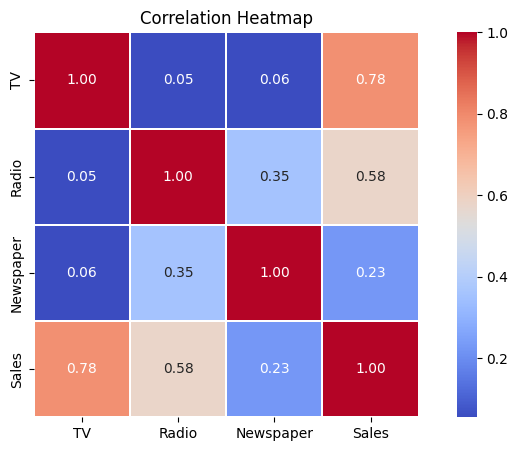

In [16]:
# Chart 2 - Correlation Heatmap

plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, linewidths=0.1, fmt='.2f', square=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insights generated:
* From the above correlation heatmap we get to know that, TV Advertising expenses and Sales are highly correlated.

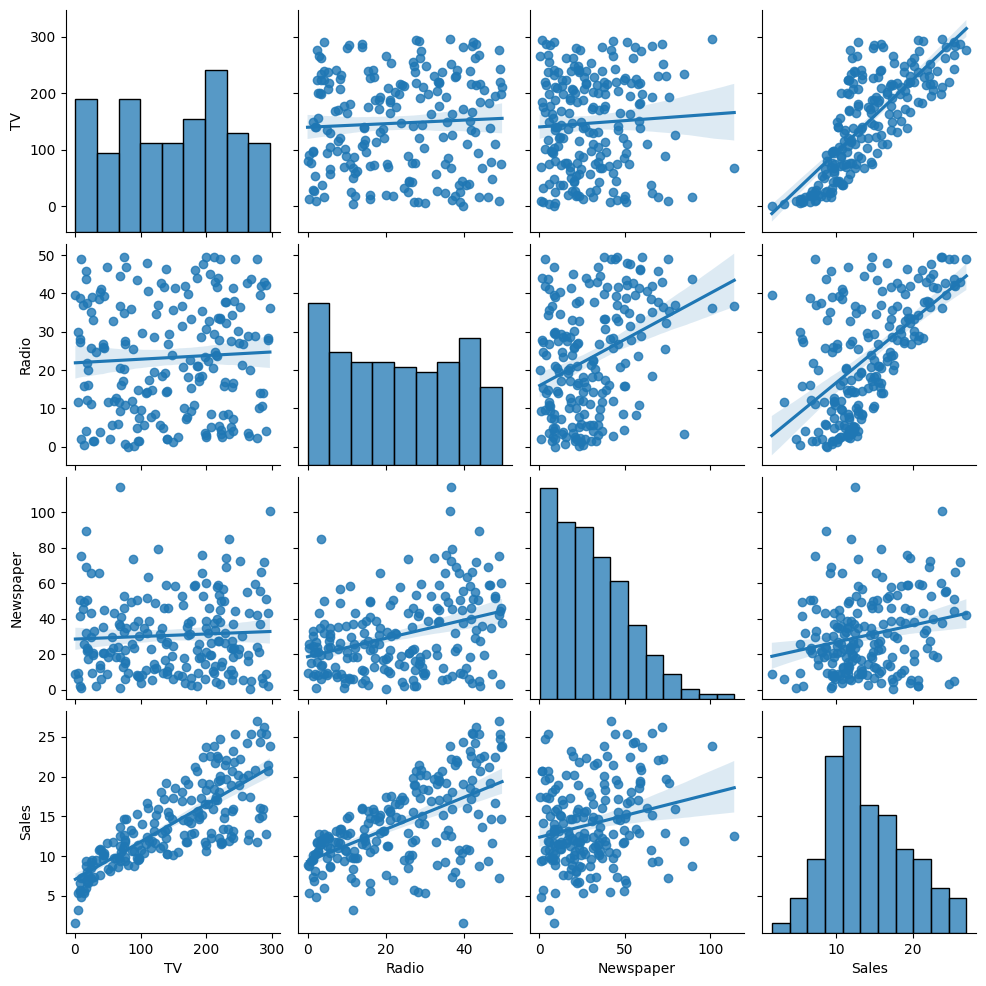

In [17]:
#Chart 3 - Pairplot
sns.pairplot(df,kind="reg");
plt.show()

## DATA PREPROCESSING

In [18]:
# Removing the outlier from newspaper
df=df[df['Newspaper']<=90]

In [19]:
# Select the features wisely to avoid overfitting
features = [i for i in df.columns if i not in ['Sales']]
features

['TV', 'Radio', 'Newspaper']

In [20]:
continuous_variables = ['TV', 'Radio', 'Newspaper']
continuous_feature_df = pd.DataFrame(df[continuous_variables])
continuous_feature_df

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [21]:
df[dependent_variable].skew()

Sales    0.40713
dtype: float64

In [22]:
# Defining dependent and independent variables
X = df.drop('Sales',axis=1)
Y = df[dependent_variable]

In [23]:
features = [i for i in df.columns if i not in ['Sales']]

In [24]:
# Scaling your data
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

## Splitting Data into Training & Testing Sets

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [26]:
Y_train.value_counts()

Sales
9.7      4
15.9     3
8.7      3
12.2     3
20.7     3
        ..
20.1     1
16.7     1
12.4     1
5.6      1
10.6     1
Name: count, Length: 109, dtype: int64

## ML Model Evaluations & Predictions

In [27]:
# Defining a function to print evaluation matrix
def evaluate_model(model, y_test, y_pred):

  '''takes model, y test and y pred values to print evaluation metrics, plot the actual and predicted values,
   and returns a list of the model scores'''

  # Calculating Evaluation Matrix
  mse = mean_squared_error(y_test,y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test,y_pred)
  y_train_pred = model.predict(X_train)  # Predict the target variable for the training set
  r2_train = r2_score(Y_train, y_train_pred)
  r2 = r2_score(y_test,y_pred)
  r2_adjusted = 1-(1-r2)*((len(X_test)-1)/(len(X_test)-X_test.shape[1]-1))

  # Printing Evaluation Matrix
  print("MSE :" , mse)
  print("RMSE :" ,rmse)
  print("MAE :" ,mae)
  print("Train R2 :" ,r2_train)
  print("Test R2 :" ,r2)
  print("Adjusted R2 : ", r2_adjusted)


  # plot actual and predicted values
  plt.figure(figsize=(12,4))
  plt.plot((y_pred)[:100])
  plt.plot((np.array(y_test)[:100]))
  plt.legend(["Predicted","Actual"])
  plt.title('Actual and Predicted Sales', fontsize=12)


  model_score = [mse,rmse,mae,r2_train,r2,r2_adjusted]
  return model_score

In [28]:
# Create a score dataframe
score = pd.DataFrame(index = ['MSE', 'RMSE', 'MAE', 'Train R2', 'Test R2', 'Adjusted R2'])

## Model 1: Linear Regression

In [29]:
# Import the LinearRegression class
reg = LinearRegression()

# Fit the linear regression model to the training data
reg.fit(X_train, Y_train)

# Predict on the model
y_pred_li = reg.predict(X_test)

MSE : 2.43207668246954
RMSE : 1.5595116807736773
MAE : 1.177152628314206
Train R2 : 0.8898322019518987
Test R2 : 0.9098946359000559
Adjusted R2 :  0.9023858555583939


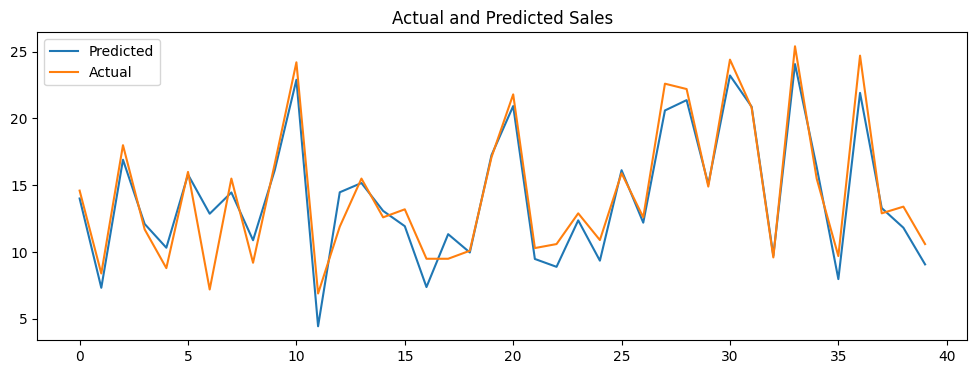

In [30]:
linear_score = evaluate_model(reg, Y_test,y_pred_li)
score['Linear regression'] = linear_score

In [33]:
score

,Linear regression
MSE,2.432077
RMSE,1.559512
MAE,1.177153
Train R2,0.889832
Test R2,0.909895
Adjusted R2,0.902386


## Model 2: Decision Tree

In [34]:
# Import Decision Tree Regressor class
dt = DecisionTreeRegressor(random_state=1)

# Fit the Decision Tree model to your training data
dt.fit(X_train,Y_train)

# Predict on the model
y_pred_dt1 = dt.predict(X_test)

MSE : 1.3222499999999997
RMSE : 1.1498912992104948
MAE : 0.9125
Train R2 : 1.0
Test R2 : 0.9510123103683663
Adjusted R2 :  0.9469300028990635


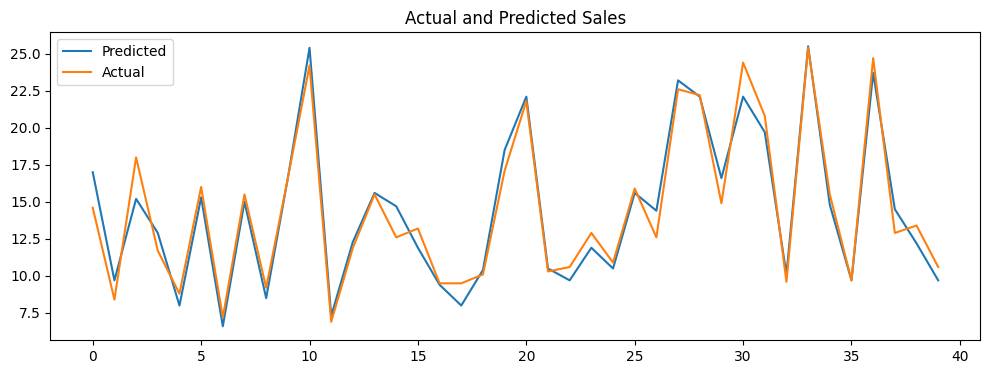

In [35]:
result = evaluate_model(dt, Y_test,y_pred_dt1)
score['Decision tree'] = result

In [36]:
score

,Linear regression,Decision tree
MSE,2.432077,1.322250
RMSE,1.559512,1.149891
MAE,1.177153,0.912500
Train R2,0.889832,1.000000
Test R2,0.909895,0.951012
Adjusted R2,0.902386,0.946930


## Model 3: Random Forest

In [37]:
# Import Random Forest Regressor class
rf = RandomForestRegressor(random_state=0)

# Fit the Random Forest model to your training data
rf.fit(X_train,Y_train)

# Predict on the model
y_pred_rf1 = rf.predict(X_test)

MSE : 0.5609009249999971
RMSE : 0.7489331912794339
MAE : 0.6069249999999967
Train R2 : 0.9969335461801611
Test R2 : 0.9792193303626424
Adjusted R2 :  0.9774876078928626


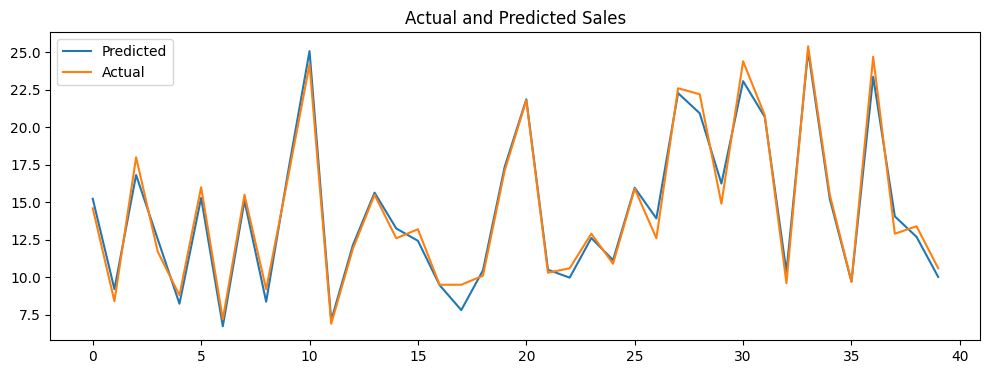

In [38]:
result = evaluate_model(rf, Y_test,y_pred_rf1)
score['Random forest'] = result

In [39]:
score

,Linear regression,Decision tree,Random forest
MSE,2.432077,1.322250,0.560901
RMSE,1.559512,1.149891,0.748933
MAE,1.177153,0.912500,0.606925
Train R2,0.889832,1.000000,0.996934
Test R2,0.909895,0.951012,0.979219
Adjusted R2,0.902386,0.946930,0.977488


## R2 Scores Graph Chart

In [43]:
score.columns

Index(['Linear regression', 'Decision tree', 'Random forest'], dtype='str')

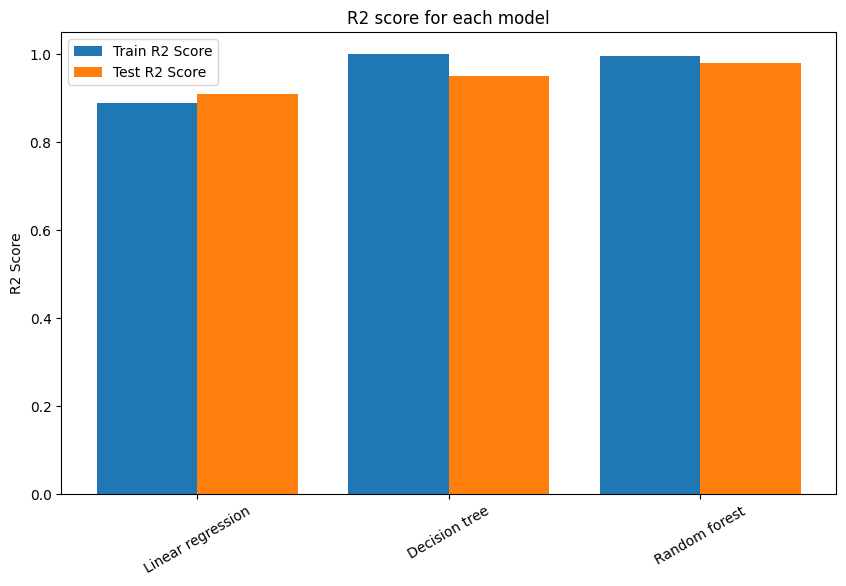

In [71]:
# R2 Scores plot

models = list(score.columns)
train = score.iloc[-3,:]
test = score.iloc[-2,:]

X_axis = np.arange(len(models))

plt.figure(figsize=(10,6))
plt.bar(X_axis - 0.2, train, 0.4, label = 'Train R2 Score')
plt.bar(X_axis + 0.2, test, 0.4, label = 'Test R2 Score')


plt.xticks(X_axis,models, rotation=30)
plt.ylabel("R2 Score")
plt.title("R2 score for each model")
plt.legend()
plt.show()

## Project Insights

### Brief Insights

- **Random Forest** performed best with the highest test R² (**0.9792**).
- It also achieved the lowest RMSE (**0.7489**) and MAE (**0.6069**).
- **Decision Tree** performed well but showed overfitting.
- **Linear Regression** provided a reliable baseline with a test R² of **0.9099**.
- TV and Radio advertising showed the strongest relationship with Sales.
- **Random Forest is the recommended model** for sales prediction.
